## Importing librairies

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# Model loading 
model = tf.keras.models.load_model('training_model.keras')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        15,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,758,735 (60.11 MB)

 Trainable params: 5,252,911 (20.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,505,824 (40.08 MB)

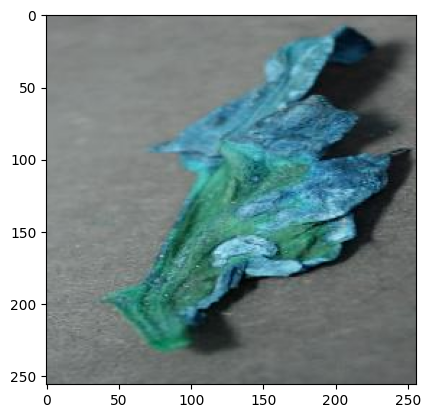

In [2]:
# Import Image

import cv2
img_path = './test/Tomato_Bacterial_spot/ffbff5e5-6c0a-4005-9974-1cb6ac61b4c9___UF.GRC_BS_Lab Leaf 1108.JPG'
img = cv2.imread(img_path)

plt.imshow(img)

## Testing Model

In [3]:
image = tf.keras.preprocessing.image.load_img(img_path, target_size=[128, 128])
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) # Convert simple image to bacth

input_arr.shape

(1, 128, 128, 3)

In [4]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


(array([[4.2144730e-08, 3.1946334e-07, 1.7583299e-07, 1.2776739e-08,
         2.3790800e-10, 1.1304841e-02, 9.8841429e-01, 2.7931063e-04,
         4.2260617e-09, 1.6150720e-07, 2.3256239e-09, 1.1486144e-07,
         4.9919709e-07, 2.2442158e-11, 6.4132998e-08]], dtype=float32),
 (1, 15))

In [5]:
result_image = np.argmax(prediction)
result_image

np.int64(6)

In [6]:
class_names = ["Pepper__bell___Bacterial_spot",   "Pepper__bell___healthy",     "Potato___Early_blight",  "Potato___Late_blight",  "Potato___healthy",       
 "Tomato_Bacterial_spot",  "Tomato_Early_blight" , "Tomato_Late_blight" , "Tomato_Leaf_Mold" , "Tomato_Septoria_leaf_spot" ,      
"Tomato_Spider_mites_Two_spotted_spider_mite" ,"Tomato__Target_Spot", "Tomato__Tomato_YellowLeaf__Curl_Virus" ,"Tomato__Tomato_mosaic_virus" ,       
 "Tomato_healthy" , ]

In [7]:
# Displaying result of disease prediction

model_prediction = class_names[result_image]
model_prediction

'Tomato_Early_blight'